 Credit Card Fraud Detection Using Anomaly Detection Techniques

 An end-to-end machine learning project that detects fraudulent credit card transactions, compares supervised and unsupervised models, and serves predictions through a web API with an interactive Transaction Risk Dashboard.

#STEP 1: IMPORT ALL THE LIBRARIES

In [21]:
# Core / Utilities
import os
import warnings
import sqlite3
import joblib
warnings.filterwarnings("ignore")

# Data Handling
import numpy as np
import pandas as pd

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# --- Preprocessing & Model Selection (Scikit-learn) ---
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler, RobustScaler

# --- Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier

# --- Imbalance Handling ---
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# --- Evaluation Metrics ---
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay
)

# import shap

# --- Database (SQL) ---
from sqlalchemy import create_engine, Column, Integer, Float, String, DateTime, ForeignKey
from sqlalchemy.orm import declarative_base, sessionmaker
from datetime import datetime

# --- Backend: choose ONE ---
# Flask
from flask import Flask, request, jsonify, render_template

# FastAPI
# from fastapi import FastAPI
# from pydantic import BaseModel
# import uvicorn
RANDOM_STATE = 42
print("All libraries imported successfully!")

All libraries imported successfully!


#STEP 2: LOAD DATASET

In [22]:
df = pd.read_csv("https://github.com/amankr0804/CREDIT-CARD-FRAUD-DETECTION/raw/refs/heads/main/dataset/creditcard.csv/creditcard.csv")

In [23]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [24]:
df.shape

(284807, 31)

#STEP 3: PREPROCESSING

In [25]:
df = df.drop_duplicates().dropna()

scaler = RobustScaler()
time_scaler = RobustScaler()

df["Amount"] = scaler.fit_transform(df[["Amount"]])
df["Time"] = time_scaler.fit_transform(df[["Time"]])
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()


Train: (226980, 30), Test: (56746, 30)


#STEP 4: DEFINE MODELS

In [26]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, class_weight="balanced_subsample",
        n_jobs=-1, random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.1,
        scale_pos_weight=neg / pos, eval_metric="aucpr",
        n_jobs=-1, random_state=RANDOM_STATE
    ),
}

iso = IsolationForest(
    n_estimators=200, contamination=float(y_train.mean()),
    n_jobs=-1, random_state=RANDOM_STATE
)


#STEP 5: TRAIN AND EVALUATE

In [27]:
# step 5.1
results, probas, preds = [], {}, {}

def add_result(name, y_true, y_pred, y_score):
    results.append({
        "Model": name,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "PR-AUC": average_precision_score(y_true, y_score),
    })
    probas[name], preds[name] = y_score, y_pred


In [28]:
# step 5.2 : supervised model
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_score = model.predict_proba(X_test)[:, 1]
    y_pred = (y_score >= 0.5).astype(int)
    add_result(name, y_test, y_pred, y_score)



Training Logistic Regression...

Training Random Forest...

Training XGBoost...


In [29]:
# step 5.3 Isolation Forest (unsupervised: trained without labels)
print("\nTraining Isolation Forest...")
iso.fit(X_train)
raw_train = -iso.score_samples(X_train)           # higher = more anomalous
raw_test = -iso.score_samples(X_test)
lo, hi = raw_train.min(), raw_train.max()
iso_score = np.clip((raw_test - lo) / (hi - lo), 0, 1)   # normalised 0-1 anomaly score
iso_pred = (iso.predict(X_test) == -1).astype(int)       # -1 = anomaly
add_result("Isolation Forest", y_test, iso_pred, iso_score)



Training Isolation Forest...


#STEP 6: COMPARISION TABLE

In [30]:
results_df = pd.DataFrame(results).set_index("Model").round(4)
print("\n================ MODEL COMPARISON ================")
print(results_df)

for name in preds:
    print(f"\n--- {name} ---")
    print(classification_report(y_test, preds[name], target_names=["Legit", "Fraud"], digits=4))



================ MODEL COMPARISON ================
                     Precision  Recall  F1-Score  ROC-AUC  PR-AUC
Model                                                            
Logistic Regression     0.0564  0.8737    0.1059   0.9657  0.6719
Random Forest           0.9714  0.7158    0.8242   0.9246  0.7978
XGBoost                 0.9136  0.7789    0.8409   0.9741  0.8283
Isolation Forest        0.2022  0.1895    0.1957   0.9304  0.1040

--- Logistic Regression ---
              precision    recall  f1-score   support

       Legit     0.9998    0.9755    0.9875     56651
       Fraud     0.0564    0.8737    0.1059        95

    accuracy                         0.9753     56746
   macro avg     0.5281    0.9246    0.5467     56746
weighted avg     0.9982    0.9753    0.9860     56746


--- Random Forest ---
              precision    recall  f1-score   support

       Legit     0.9995    1.0000    0.9997     56651
       Fraud     0.9714    0.7158    0.8242        95

    accur

#STEP 7: PLOTS

In [31]:
os.makedirs("reports", exist_ok=True)

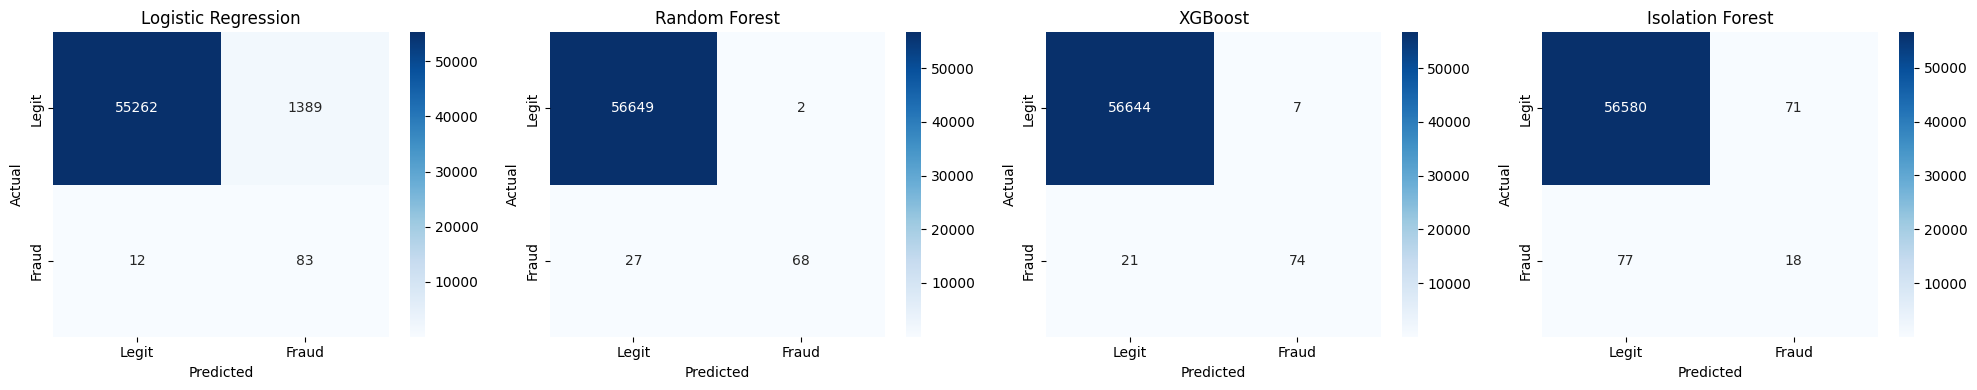

In [32]:
# step 7.1 confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, name in zip(axes, preds):
    sns.heatmap(confusion_matrix(y_test, preds[name]), annot=True, fmt="d",
                cmap="Blues", ax=ax, xticklabels=["Legit", "Fraud"],
                yticklabels=["Legit", "Fraud"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("reports/confusion_matrices.png", dpi=150)


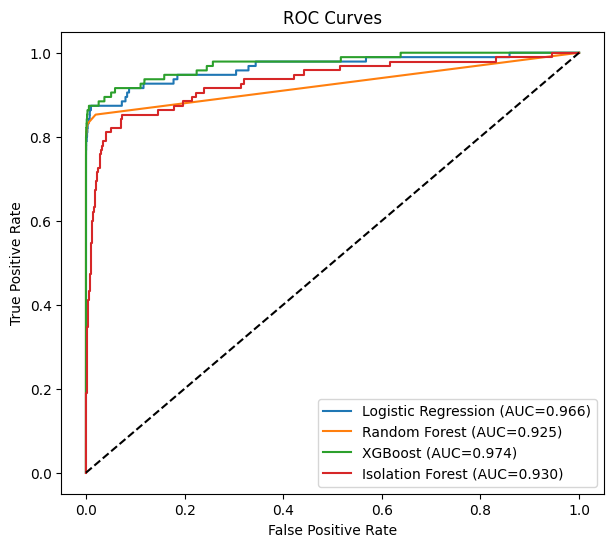

In [33]:
# step 7.2 ROC curves
plt.figure(figsize=(7, 6))
for name, score in probas.items():
    fpr, tpr, _ = roc_curve(y_test, score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, score):.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.savefig("reports/roc_curves.png", dpi=150)


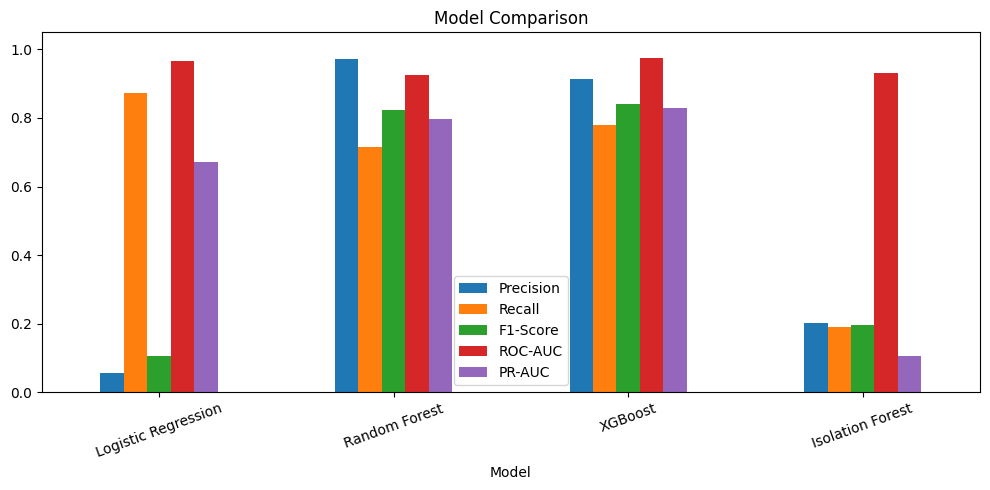

In [34]:
# step 7.3 metrics bar chart
results_df.plot(kind="bar", figsize=(10, 5))
plt.title("Model Comparison")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("reports/model_comparison.png", dpi=150)


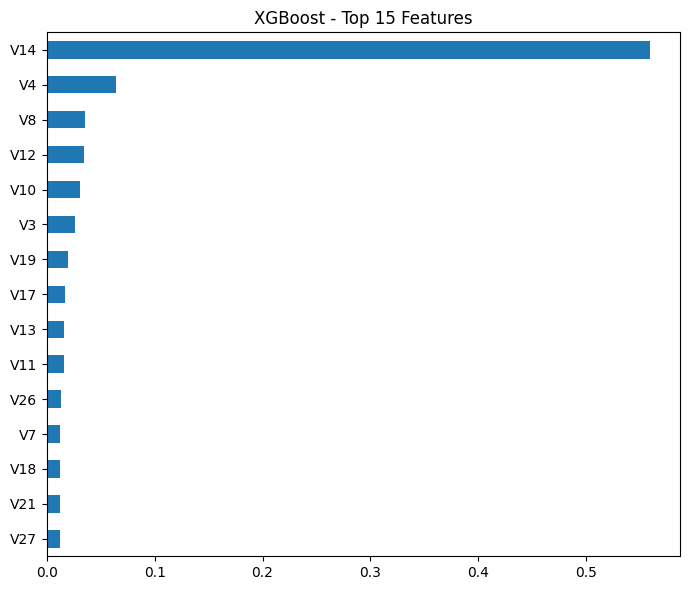

In [35]:
# step 7.4 Feature importance (XGBoost)
imp = pd.Series(models["XGBoost"].feature_importances_, index=X.columns)
imp.nlargest(15).sort_values().plot(kind="barh", figsize=(7, 6), title="XGBoost - Top 15 Features")
plt.tight_layout()
plt.savefig("reports/feature_importance.png", dpi=150)


#STEP 8: SAVE MODELS

In [36]:
os.makedirs("models", exist_ok=True)

for name, model in models.items():
    joblib.dump(
        model,
        f"models/{name.lower().replace(' ', '_')}.pkl"
    )

joblib.dump(iso, "models/isolation_forest.pkl")

joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(time_scaler, "models/time_scaler.pkl")

results_df.to_csv("reports/metrics.csv")

print("Models and scalers saved successfully!")

Models and scalers saved successfully!


# STEP 9: RISK SCORING HELPER (FOR API'S AND DASHBOARD)

In [37]:
def risk_level(p: float) -> str:
    if p < 0.30:
        return "Low"
    if p < 0.60:
        return "Medium"
    if p < 0.85:
        return "High"
    return "Critical"

best_model = models["XGBoost"]
sample = X_test.head(10).copy()
sample["fraud_probability"] = best_model.predict_proba(X_test.head(10))[:, 1].round(4)
sample["risk_level"] = sample["fraud_probability"].apply(risk_level)
sample["actual"] = y_test.head(10).values
print("\nSample predictions:")
print(sample[["fraud_probability", "risk_level", "actual"]])



Sample predictions:
        fraud_probability risk_level  actual
86568              0.0000        Low       0
251557             0.0000        Low       0
20232              0.0000        Low       0
68952              0.0000        Low       0
191852             0.0001        Low       0
94289              0.0000        Low       0
16245              0.0000        Low       0
16056              0.0000        Low       0
158543             0.0000        Low       0
212344             0.0000        Low       0
